# **1. Chuẩn bị dữ liệu**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load dữ liệu đã clean từ notebook 02
df = pd.read_csv('../data/processed/migration_data_processed_2000_2022.csv')

# Danh sách biến tối ưu từ Notebook 06 (LASSO/BMA)
features = [c for c in df.columns if "PC" in c]

X = df[features]
y = df['ln_migration']

# Chia train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

C:\Users\gbaon\AppData\Local\Temp\ipykernel_2636\395049232.py:11: DtypeWarning: Columns (31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/processed/migration_data_processed_2000_2022.csv')


In [2]:
features

['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6']

# **2. Mô hình Random Forest**

In [3]:
# Cấu hình Random Forest
rf_model = RandomForestRegressor(n_estimators=500, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Dự báo và đánh giá
y_pred_rf = rf_model.predict(X_test)
print(f"RF R-squared: {r2_score(y_test, y_pred_rf):.4f}")
print(f"RF RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.4f}")

RF R-squared: 0.8088
RF RMSE: 0.9302


# **3. Mô hình XGBoost**

In [4]:
# Cấu hình XGBoost với Regularization để tránh Overfitting
xgb_model = XGBRegressor(
    n_estimators=1000, 
    learning_rate=0.05, 
    max_depth=6, 
    reg_alpha=0.1, # L1 regularization
    reg_lambda=1,  # L2 regularization
    random_state=42
)
xgb_model.fit(X_train, y_train)

# Dự báo và đánh giá
y_pred_xgb = xgb_model.predict(X_test)
print(f"XGB R-squared: {r2_score(y_test, y_pred_xgb):.4f}")
print(f"XGB RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.4f}")

XGB R-squared: 0.7989
XGB RMSE: 0.9540


# **4. So sánh Random Forest và XGBoost**

C:\Users\gbaon\AppData\Local\Temp\ipykernel_2636\1402778065.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_importance, y=rf_importance.index, ax=axes[0], palette='viridis')
C:\Users\gbaon\AppData\Local\Temp\ipykernel_2636\1402778065.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=xgb_importance, y=xgb_importance.index, ax=axes[1], palette='magma')


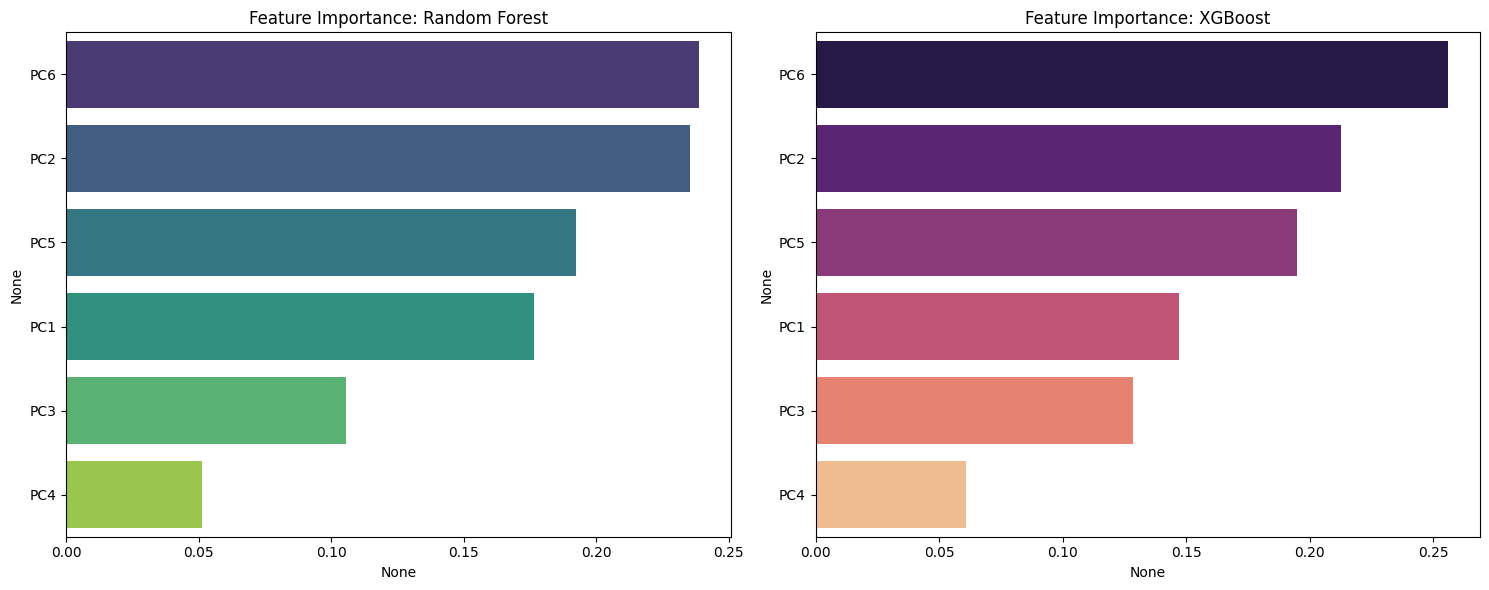

In [5]:
# Lấy feature importance từ hai mô hình
rf_importance = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)
xgb_importance = pd.Series(xgb_model.feature_importances_, index=features).sort_values(ascending=False)

# Trực quan hóa
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(x=rf_importance, y=rf_importance.index, ax=axes[0], palette='viridis')
axes[0].set_title('Feature Importance: Random Forest')

sns.barplot(x=xgb_importance, y=xgb_importance.index, ax=axes[1], palette='magma')
axes[1].set_title('Feature Importance: XGBoost')

plt.tight_layout()
plt.show()

C:\Users\gbaon\AppData\Local\Temp\ipykernel_2636\1402778065.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_importance, y=rf_importance.index, ax=axes[0], palette='viridis')
C:\Users\gbaon\AppData\Local\Temp\ipykernel_2636\1402778065.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=xgb_importance, y=xgb_importance.index, ax=axes[1], palette='magma')


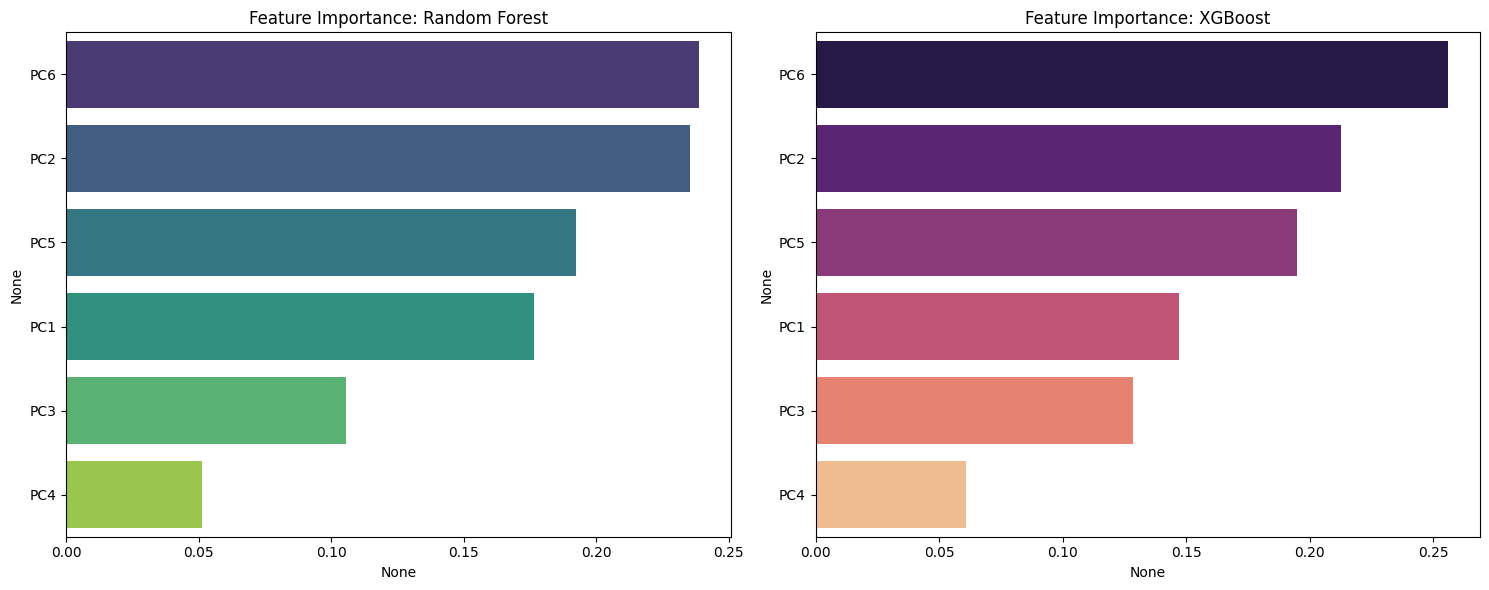

In [6]:
# Lấy feature importance từ hai mô hình
rf_importance = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)
xgb_importance = pd.Series(xgb_model.feature_importances_, index=features).sort_values(ascending=False)

# Trực quan hóa
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(x=rf_importance, y=rf_importance.index, ax=axes[0], palette='viridis')
axes[0].set_title('Feature Importance: Random Forest')

sns.barplot(x=xgb_importance, y=xgb_importance.index, ax=axes[1], palette='magma')
axes[1].set_title('Feature Importance: XGBoost')

plt.tight_layout()
plt.show()

In [11]:
feats_imp = pd.DataFrame({
    "features importance rf": rf_importance,
    "features importance xgb": xgb_importance
})
feats_imp

,features importance rf,features importance xgb
PC6,0.238748,0.256132
PC2,0.235448,0.212623
PC5,0.192306,0.194929
PC1,0.176472,0.147233
PC3,0.105652,0.128399
PC4,0.051375,0.060685


# **5. Mô hình LightGBM**

In [7]:
from lightgbm import LGBMRegressor

# Cấu hình LightGBM 
# Leaf-wise growth giúp mô hình hội tụ nhanh và chính xác hơn trên dữ liệu phức tạp
lgbm_model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    feature_fraction=0.9,
    bagging_fraction=0.8,
    random_state=42,
    n_jobs=-1
)

lgbm_model.fit(X_train, y_train)

# Dự báo và đánh giá
y_pred_lgbm = lgbm_model.predict(X_test)
print(f"LightGBM R-squared: {r2_score(y_test, y_pred_lgbm):.4f}")
print(f"LightGBM RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lgbm)):.4f}")

[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000517 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 6688, number of used features: 6
[LightGBM] [Info] Start training from score 9.093950
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.8, subs

<Axes: >

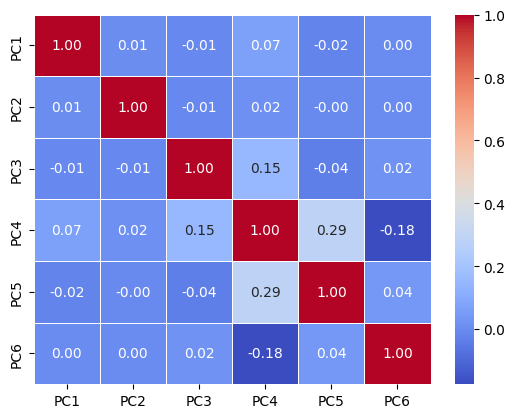

In [8]:
cols_to_check = [
    'ln_migration', 'ln_gdp_org', 'ln_gdp_des', 'ln_pop_org', 'ln_pop_des',
    'ln_dist', 'comlang_off', 'contig', 'ln_co2_org', 'ln_pm25_org',
    'ln_internet_use_org', 'ln_bandwidth_org', 'ln_disaster_org', 'ln_disaster_des'
]

# Filter to only include columns that exist in the dataframe
cols_to_check = [c for c in features if c in df.columns]

# Calculate correlation matrix
corr_matrix = df[cols_to_check].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)